<a href="https://colab.research.google.com/github/ymuto0302/RW2025/blob/main/GTSRB_dataset_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GTSRB dataset に含まれるデータの可視化

In [1]:
!pip install japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 39.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=48680201bcae27f911cb63129461a98c8426fb01a9e46a015f398242c9153846
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib


訓練データ数: 26640
クラス数: 43


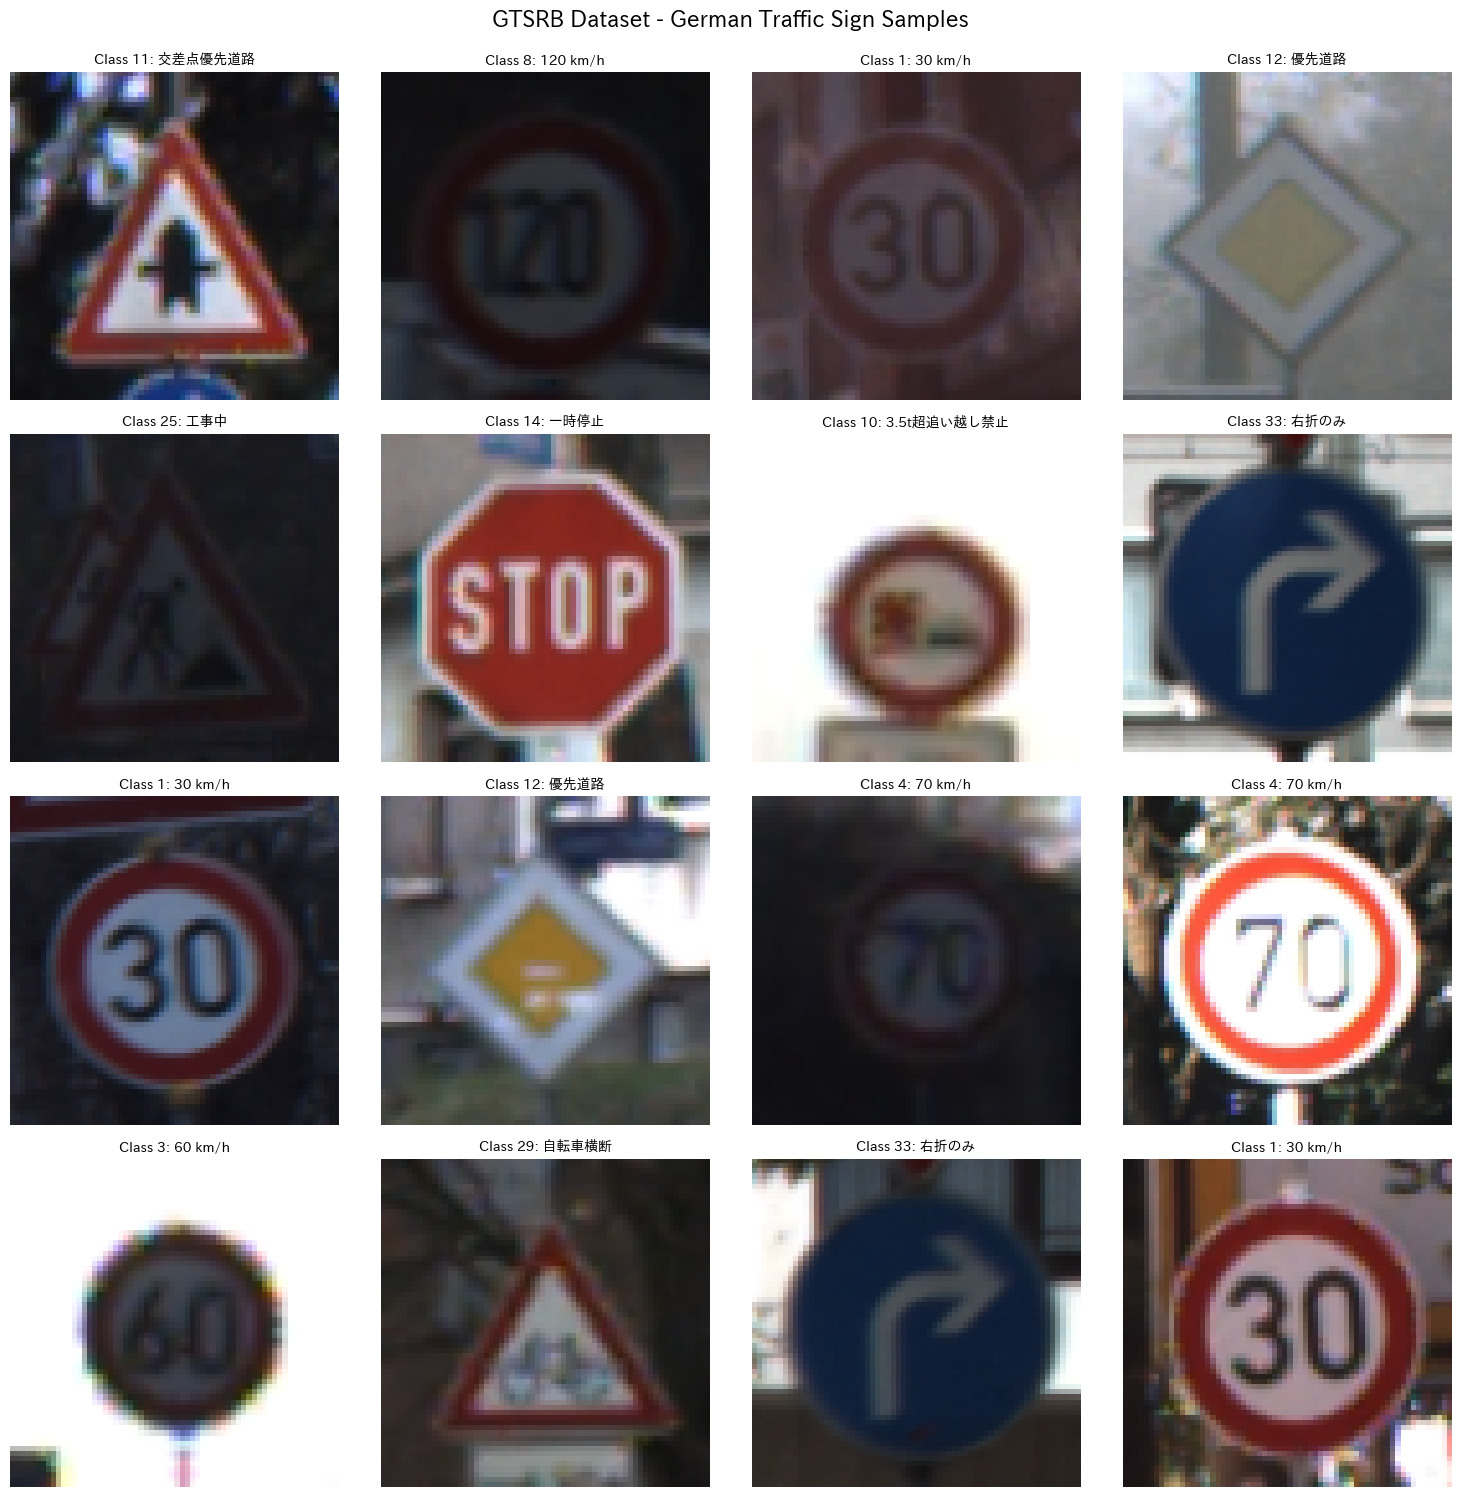

In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import GTSRB
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np

# データセットの読み込み（可視化用に正規化なし）
visualization_transform = transforms.Compose([
    transforms.Resize((64, 64)),  # 表示用にリサイズ
    transforms.ToTensor()
])

train_dataset = GTSRB(root='./data', split='train', download=True,
                      transform=visualization_transform)

print(f'訓練データ数: {len(train_dataset)}')
print(f'クラス数: 43')

# クラス名のマッピング（ドイツ交通標識の説明）
class_names = [
    '20 km/h', '30 km/h', '50 km/h', '60 km/h', '70 km/h',
    '80 km/h', '80 km/h解除', '100 km/h', '120 km/h', '追い越し禁止',
    '3.5t超追い越し禁止', '交差点優先道路', '優先道路', '譲れ', '一時停止',
    '進入禁止', '3.5t超進入禁止', '進入禁止(一般)', '注意', '左カーブ',
    '右カーブ', 'S字カーブ', 'でこぼこ道', '滑りやすい路面', '右側狭い',
    '工事中', '信号あり', '歩行者', '子供注意', '自転車横断',
    '雪・氷注意', '野生動物', '制限解除', '右折のみ', '左折のみ',
    '直進のみ', '直進または右折', 'ロータリー', '追い越し禁止解除',
    '3.5t超追い越し禁止解除'
]

# ランダムに16枚の画像を選択して表示
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
fig.suptitle('GTSRB Dataset - German Traffic Sign Samples', fontsize=16, y=0.995)

# ランダムにインデックスを選択
np.random.seed(42)
random_indices = np.random.choice(len(train_dataset), 16, replace=False)

for idx, ax in enumerate(axes.flat):
    img, label = train_dataset[random_indices[idx]]

    # Tensor を numpy array に変換
    img_np = img.permute(1, 2, 0).numpy()

    ax.imshow(img_np)
    ax.set_title(f'Class {label}: {class_names[label]}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()